Independent AR(1) per state — naive baseline, no pooling.

$$\alpha_s \sim \mathcal{N}(5, 3), \quad \beta_s \sim \mathcal{N}(0.5, 0.3), \quad \sigma \sim \text{Exp}(1)$$
$$y_{s,t} \mid \alpha_s, \beta_s, \sigma \sim \mathcal{N}(\alpha_s + \beta_s\, y_{s,t-1},\ \sigma)$$

## 1. Setup

In [1]:
library(cmdstanr)
library(dplyr)
library(tidyr)
library(ggplot2)
set.seed(405)

dir.create("../results", showWarnings = FALSE)

TRAIN_END <- as.Date("2023-12-01")

This is cmdstanr version 0.9.0.9000

- CmdStanR documentation and vignettes: mc-stan.org/cmdstanr

- CmdStan path: /Users/calvindu/.cmdstan/cmdstan-2.38.0

- CmdStan version: 2.38.0


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'ggplot2' was built under R version 4.3.3"


## 2. Load and prepare data

In [2]:
bls <- read.csv("../cleaned_data/bls_data.csv") %>%
  mutate(date = as.Date(date))


bls_train <- bls %>%
  filter(date <= TRAIN_END) %>%
  arrange(state, date) %>%
  group_by(state) %>%
  mutate(
    bls_lag = lag(unemployment_rate),
    state_id = cur_group_id()
  ) %>%
  filter(!is.na(bls_lag)) %>%
  ungroup()

bls_test <- bls %>%
  filter(date > TRAIN_END) %>%
  arrange(state, date) %>%
  group_by(state) %>%
  mutate(bls_lag = lag(unemployment_rate, default = NA)) %>%
  ungroup()

last_train <- bls %>%
  filter(date == TRAIN_END) %>%
  arrange(state) %>%
  select(state, last_ur = unemployment_rate)

bls_test <- bls_test %>%
  group_by(state) %>%
  mutate(
    bls_lag = lag(unemployment_rate),
    bls_lag = if_else(is.na(bls_lag),
                      last_train$last_ur[match(state, last_train$state)],
                      bls_lag),
    state_id = cur_group_id()
  ) %>%
  ungroup()

states <- sort(unique(bls_train$state))
S <- length(states)
N <- nrow(bls_train)
N_test <- nrow(bls_test)

print(paste("Number of states:", S))
print(paste("Number of observations:", N))
head(bls_train)


[1] "Number of states: 50"
[1] "Number of observations: 28750"


state,date,population,unemployed_population,unemployment_rate,bls_lag,state_id
<chr>,<date>,<int>,<int>,<dbl>,<dbl>,<int>
AK,1976-02-01,160551,11426,7.1,7.1,1
AK,1976-03-01,160663,11313,7.0,7.1,1
AK,1976-04-01,161579,11286,7.0,7.0,1
AK,1976-05-01,162885,11395,7.0,7.0,1
AK,1976-06-01,164431,11687,7.1,7.0,1
AK,1976-07-01,165869,12181,7.3,7.1,1


## 3. Compile and sample

In [3]:
mod1 <- cmdstan_model("model1.stan")

stan_data <- list(
  N = N, 
  S = S,
  y = bls_train$unemployment_rate,
  y_lag = bls_train$bls_lag,
  state_id = bls_train$state_id,
  N_test = N_test,
  y_lag_test = bls_test$bls_lag,
  state_id_test = bls_test$state_id
)

fit1 <- mod1$sample(
  data = stan_data,
  seed = 405,
  chains = 4,
  parallel_chains = 4,
  iter_warmup = 1000,
  iter_sampling = 1000,
  refresh = 250
)

fit1$save_object("../results/model1_fit.rds")

Running MCMC with 4 parallel chains...

Chain 1 Iteration:    1 / 2000 [  0%]  (Warmup) 
Chain 2 Iteration:    1 / 2000 [  0%]  (Warmup) 


Chain 2 Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:

Chain 2 Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/var/folders/y3/gl0m1z2n7vs9dg6j1b92szsm0000gn/T/Rtmp3jpYzj/model-175584362c878.stan', line 25, column 4 to column 76)

Chain 2 If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,

Chain 2 but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.

Chain 2 

Chain 2 Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:

Chain 2 Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/var/folders/y3/gl0m1z2n7vs9dg6j1b92szsm0000gn/T/Rtmp3jpYzj/model-175584362c878.stan', line 25, column 4 to column 76)

Chain 2 If this warning occurs sporadically, such as for highly constrained variable types

Chain 3 Iteration:    1 / 2000 [  0%]  (Warmup) 
Chain 4 Iteration:    1 / 2000 [  0%]  (Warmup) 
Chain 4 Iteration:  250 / 2000 [ 12%]  (Warmup) 
Chain 2 Iteration:  250 / 2000 [ 12%]  (Warmup) 
Chain 3 Iteration:  250 / 2000 [ 12%]  (Warmup) 
Chain 1 Iteration:  250 / 2000 [ 12%]  (Warmup) 
Chain 4 Iteration:  500 / 2000 [ 25%]  (Warmup) 
Chain 2 Iteration:  500 / 2000 [ 25%]  (Warmup) 
Chain 3 Iteration:  500 / 2000 [ 25%]  (Warmup) 
Chain 1 Iteration:  500 / 2000 [ 25%]  (Warmup) 
Chain 4 Iteration:  750 / 2000 [ 37%]  (Warmup) 
Chain 2 Iteration:  750 / 2000 [ 37%]  (Warmup) 
Chain 3 Iteration:  750 / 2000 [ 37%]  (Warmup) 
Chain 1 Iteration:  750 / 2000 [ 37%]  (Warmup) 
Chain 4 Iteration: 1000 / 2000 [ 50%]  (Warmup) 
Chain 4 Iteration: 1001 / 2000 [ 50%]  (Sampling) 
Chain 2 Iteration: 1000 / 2000 [ 50%]  (Warmup) 
Chain 2 Iteration: 1001 / 2000 [ 50%]  (Sampling) 
Chain 3 Iteration: 1000 / 2000 [ 50%]  (Warmup) 
Chain 3 Iteration: 1001 / 2000 [ 50%]  (Sampling) 
Chain 1 Iterat

## 4. Diagnostics

In [4]:

diag <- fit1$summary(c("alpha", "beta", "sigma")) %>%
  select(variable, mean, sd, q5, q95, rhat, ess_bulk, ess_tail)

print(paste("R-hat range: ", paste(range(diag$rhat), collapse = " - ")))
print(paste("Bulk ESS range: ", paste(range(diag$ess_bulk), collapse = " - ")))
print(paste("Tail ESS range: ", paste(range(diag$ess_tail), collapse = " - ")))

[1] "R-hat range:  0.999422657405822 - 1.00629060087864"
[1] "Bulk ESS range:  5013.23452451007 - 12104.0847678058"
[1] "Tail ESS range:  2258.31849952343 - 3302.95297476117"


## 5. Trace plots

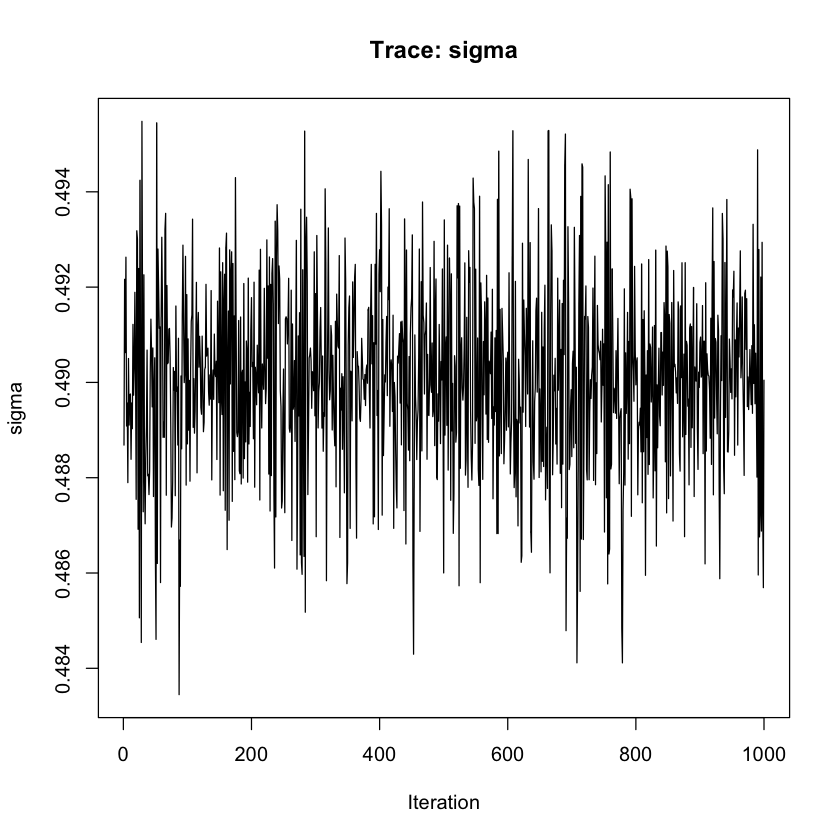

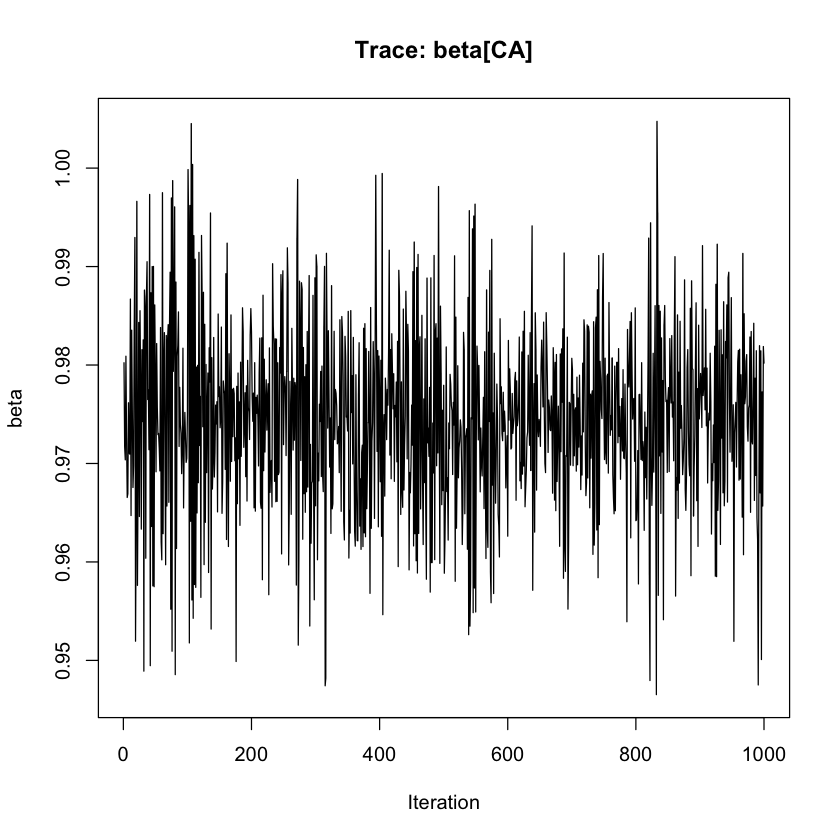

In [5]:
draws <- fit1$draws(format = "df")

plot(draws$sigma[draws$.chain == 1], type = "l", main = "Trace: sigma", xlab = "Iteration", ylab = "sigma")

ca_idx <- match("CA", states)
plot(draws[[paste0("beta[", ca_idx, "]")]][draws$.chain == 1], type = "l", main = "Trace: beta[CA]", xlab = "Iteration", ylab = "beta")

## 6. Posterior beta_s across all states

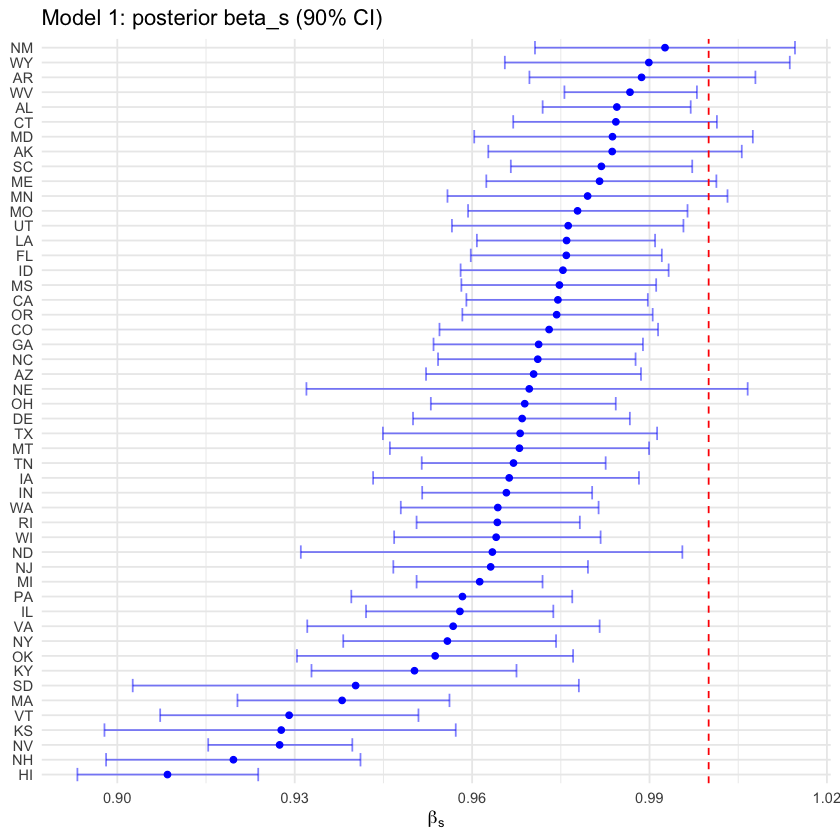

In [6]:
beta_summary <- fit1$summary("beta") %>%
  mutate(state = states)

p_beta <- ggplot(beta_summary, aes(x = reorder(state, mean), y = mean)) +
  geom_point(colour = "blue") +
  geom_errorbar(aes(ymin = q5, ymax = q95), colour = "blue", alpha = 0.5) +
  geom_hline(yintercept = 1, linetype = "dashed", colour = "red") +
  labs(title = "Model 1: posterior beta_s (90% CI)", x = NULL, y = expression(beta[s])) +
  coord_flip() +
  theme_minimal()

p_beta

## 8. Posterior predictive check (PPC)

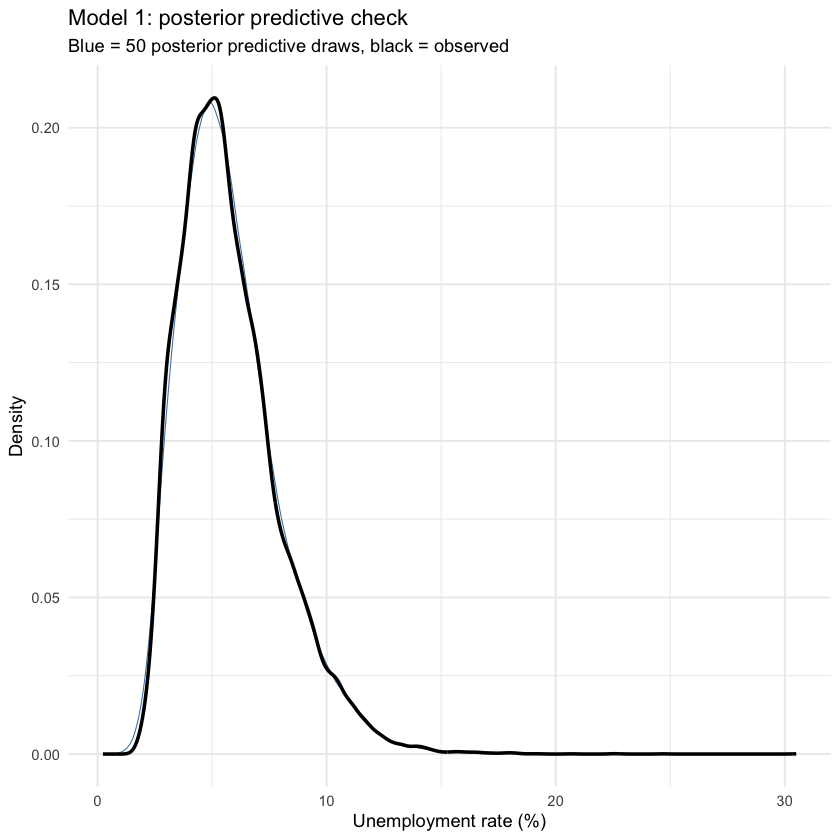

In [7]:
y_rep_draws <- fit1$draws("y_rep", format = "matrix")
rep_idx <- sample(nrow(y_rep_draws), 50)

rep_df <- data.frame(
  value  = as.vector(y_rep_draws[rep_idx, ]),
  source = "y_rep"
)
obs_df <- data.frame(
  value  = bls_train$unemployment_rate,
  source = "observed"
)

p_ppc <- ggplot() +
  geom_density(data = rep_df, aes(x = value, group = source),
               colour = "steelblue", alpha = 0.15, linewidth = 0.3) +
  geom_density(data = obs_df, aes(x = value),
               colour = "black", linewidth = 1) +
  labs(
    title = "Model 1: posterior predictive check",
    subtitle = "Blue = 50 posterior predictive draws, black = observed",
    x = "Unemployment rate (%)", y = "Density"
  ) +
  theme_minimal()

p_ppc

## 9. Test-set RMSE

In [8]:
alpha_hat <- fit1$summary("alpha")$mean
beta_hat  <- fit1$summary("beta")$mean

bls_test <- bls %>% filter(date > TRAIN_END) %>% arrange(state, date)
test_dates <- sort(unique(bls_test$date))

# Last training observation per state
y_prev <- bls_train %>% filter(date == TRAIN_END) %>% arrange(state) %>% pull(unemployment_rate)

forecast_list <- vector("list", length(test_dates))

for (i in seq_along(test_dates)) {
  y_pred   <- alpha_hat + beta_hat * y_prev
  y_actual <- bls_test |>
    filter(date == test_dates[i]) |>
    arrange(state) |>
    pull(unemployment_rate)

  forecast_list[[i]] <- data.frame(
    state    = states,
    date     = test_dates[i],
    y_pred   = y_pred,
    y_actual = y_actual
  )
  y_prev <- y_actual
}

forecasts1 <- bind_rows(forecast_list)

rmse1 <- forecasts1 %>%
  group_by(state) %>%
  summarise(rmse = sqrt(mean((y_pred - y_actual)^2)), .groups = "drop") %>% 
  arrange(desc(rmse))

print('Model 1 overall RMSE:')
print(round(sqrt(mean((forecasts1$y_pred - forecasts1$y_actual)^2)), 3))
print('Worst 5 states:');
print(head(rmse1, 5))
print('Best 5 states:');
print(tail(rmse1, 5))

[1] "Model 1 overall RMSE:"
[1] 0.096
[1] "Worst 5 states:"
# A tibble: 5 x 2
  state  rmse
  <chr> <dbl>
1 HI    0.214
2 DE    0.134
3 IN    0.129
4 KY    0.125
5 IL    0.124
[1] "Best 5 states:"
# A tibble: 5 x 2
  state   rmse
  <chr>  <dbl>
1 AR    0.0636
2 OR    0.0609
3 ND    0.0533
4 NE    0.0468
5 KS    0.0446


## 10. Forecast

In [17]:
pred_draws <- fit1$draws("y_pred", format = "matrix")

pred <- data.frame(
  state    = bls_test$state,
  date     = bls_test$date,
  y_actual = bls_test$unemployment_rate,
  y_mean   = colMeans(pred_draws),
  y_q05    = apply(pred_draws, 2, quantile, 0.05),
  y_q25    = apply(pred_draws, 2, quantile, 0.25),
  y_q75    = apply(pred_draws, 2, quantile, 0.75),
  y_q95    = apply(pred_draws, 2, quantile, 0.95)
)

head(pred)

,state,date,y_actual,y_mean,y_q05,y_q25,y_q75,y_q95
,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
y_pred[1],AK,2024-01-01,4.4,4.550531,3.723812,4.222649,4.884196,5.358473
y_pred[2],AK,2024-02-01,4.4,4.445579,3.642818,4.118423,4.774736,5.254031
y_pred[3],AK,2024-03-01,4.4,4.441712,3.621738,4.110280,4.765199,5.270102
y_pred[4],AK,2024-04-01,4.5,4.450396,3.616712,4.117122,4.784482,5.254693
y_pred[5],AK,2024-05-01,4.5,4.539028,3.756228,4.210160,4.866503,5.310467
y_pred[6],AK,2024-06-01,4.6,4.565042,3.753405,4.233077,4.900881,5.355349


In [18]:
coverage <- function(pred, lo, hi, label) {
  cov <- mean(pred$y_actual >= lo & pred$y_actual <= hi)
  cat(sprintf("%s coverage: %.1f%% (nominal %.0f%%)\n",
              label, cov * 100,
              as.numeric(gsub("y_q|y_q", "", deparse(substitute(hi)))) -
              as.numeric(gsub("y_q|y_q", "", deparse(substitute(lo))))))
}

cat("90% interval coverage:",
    round(mean(pred$y_actual >= pred$y_q05 & pred$y_actual <= pred$y_q95), 3), "\n")
cat("50% interval coverage:",
    round(mean(pred$y_actual >= pred$y_q25 & pred$y_actual <= pred$y_q75), 3), "\n")
cat("Mean 90% interval width:",
    round(mean(pred$y_q95 - pred$y_q05), 3), "\n")

90% interval coverage: 1 
50% interval coverage: 0.995 
Mean 90% interval width: 1.614 


In [15]:
round(sqrt(mean((pred$y_mean - pred$y_actual)^2)), 3)

[1] 0.097

## 10.2 Forecast Plot

In [ ]:
plot_states <- c("CA", "TX", "MI", "NV")

par(mfrow = c(2, 2))

for (s in plot_states) {
  obs  <- bls %>% filter(state == s) %>% arrange(date)
  pred <- forecasts1 %>% filter(state == s) %>% arrange(date)
  
  plot(obs$date, obs$unemployment_rate, type = "l", main = s, xlab = "Year", ylab = "Unemployment (%)")
  lines(pred$date, pred$y_pred, col = "blue")
}

par(mfrow = c(1, 1))

## 11. VI

In [ ]:
mod1 <- cmdstan_model("model1.stan")

fit1 <- readRDS("../results/model1_fit.rds")
fit1_vi <- mod1$variational(
  data      = stan_data,
  seed      = 405,
  algorithm = "meanfield",
  draws     = 1000
)

print(fit1_vi$summary(c("sigma", "beta[1]", "beta[6]")))

params <- paste0("beta[", match(c("CA", "TX", "MI", "NV"), states), "]")

hmc_sum <- fit1$summary(params) %>%
  select(variable, mean, q5, q95) %>%
  mutate(method = "HMC")

vi_sum <- fit1_vi$summary(params) %>%
  select(variable, mean, q5, q95) %>%
  mutate(method = "VI")

bind_rows(hmc_sum, vi_sum) %>%
  ggplot(aes(x = variable, y = mean, colour = method)) +
  geom_point(position = position_dodge(0.4)) +
  geom_errorbar(aes(ymin = q5, ymax = q95),
                width = 0.2, position = position_dodge(0.4)) +
  labs(title = "Model 1: HMC vs VI", x = NULL, y = "beta_s") +
  theme_minimal()

# 12. Save

In [19]:
saveRDS(list(
  beta_hat = beta_hat,
  alpha_hat = alpha_hat,
  forecasts = forecasts1
), "../results/model1_results.rds")